In [1]:
import os
import h5py
from torch_brain.data import Data
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

In [2]:
# BIDS_ROOT = ("/capstor/scratch/cscs/davalos/data/processed/omni_ieeg")
# H5_FILENAME = "sub-openieegDetroit078_ses-01_task-sleep.h5"
BIDS_ROOT = ("/Users/avalos/Documents/Programming/neurosoft_epilepsy/data/processed/omni_ieeg")
H5_FILENAME="sub-openieegDetroit006_ses-01_task-sleep.h5"

### 1. Load .h5 file

In [3]:
with h5py.File(os.path.join(BIDS_ROOT, H5_FILENAME), "r") as f:
    data = Data.from_hdf5(f, lazy=False)

    print("Fields in data:")
    for key in data.keys():
        print("   - ", key)

Fields in data:
   -  annotations
   -  brainset
   -  channels
   -  device
   -  ieeg
   -  session
   -  subject
   -  dataset_name
   -  outcome
   -  split
   -  task_name


In [4]:
print(data.annotations)

Interval(
  start=[332],
  end=[332],
  artifact=[332],
  channel=[332],
  description=[332],
  detector=[332],
  method=[332],
  spike=[332]
)


In [6]:
data.ieeg

RegularTimeSeries(
  signal=[304000, 100]
)

### 2. Channels info

In [7]:
print("Channel names: ", data.channels.id[1:5])
print("Channel types: ", data.channels.type[1:5])

Channel names:  ['A2-AV' 'A3-AV' 'A4-AV' 'A5-AV']
Channel types:  ['eeg' 'eeg' 'eeg' 'eeg']


In [8]:
ch_names=data.channels.id
ch_types=data.channels.type
start_time=0
signal = data.ieeg.signal # ecog
timestamps = data.ieeg.timestamps # ecog
timestamps
len(ch_names)
np.arange(len(ch_names))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

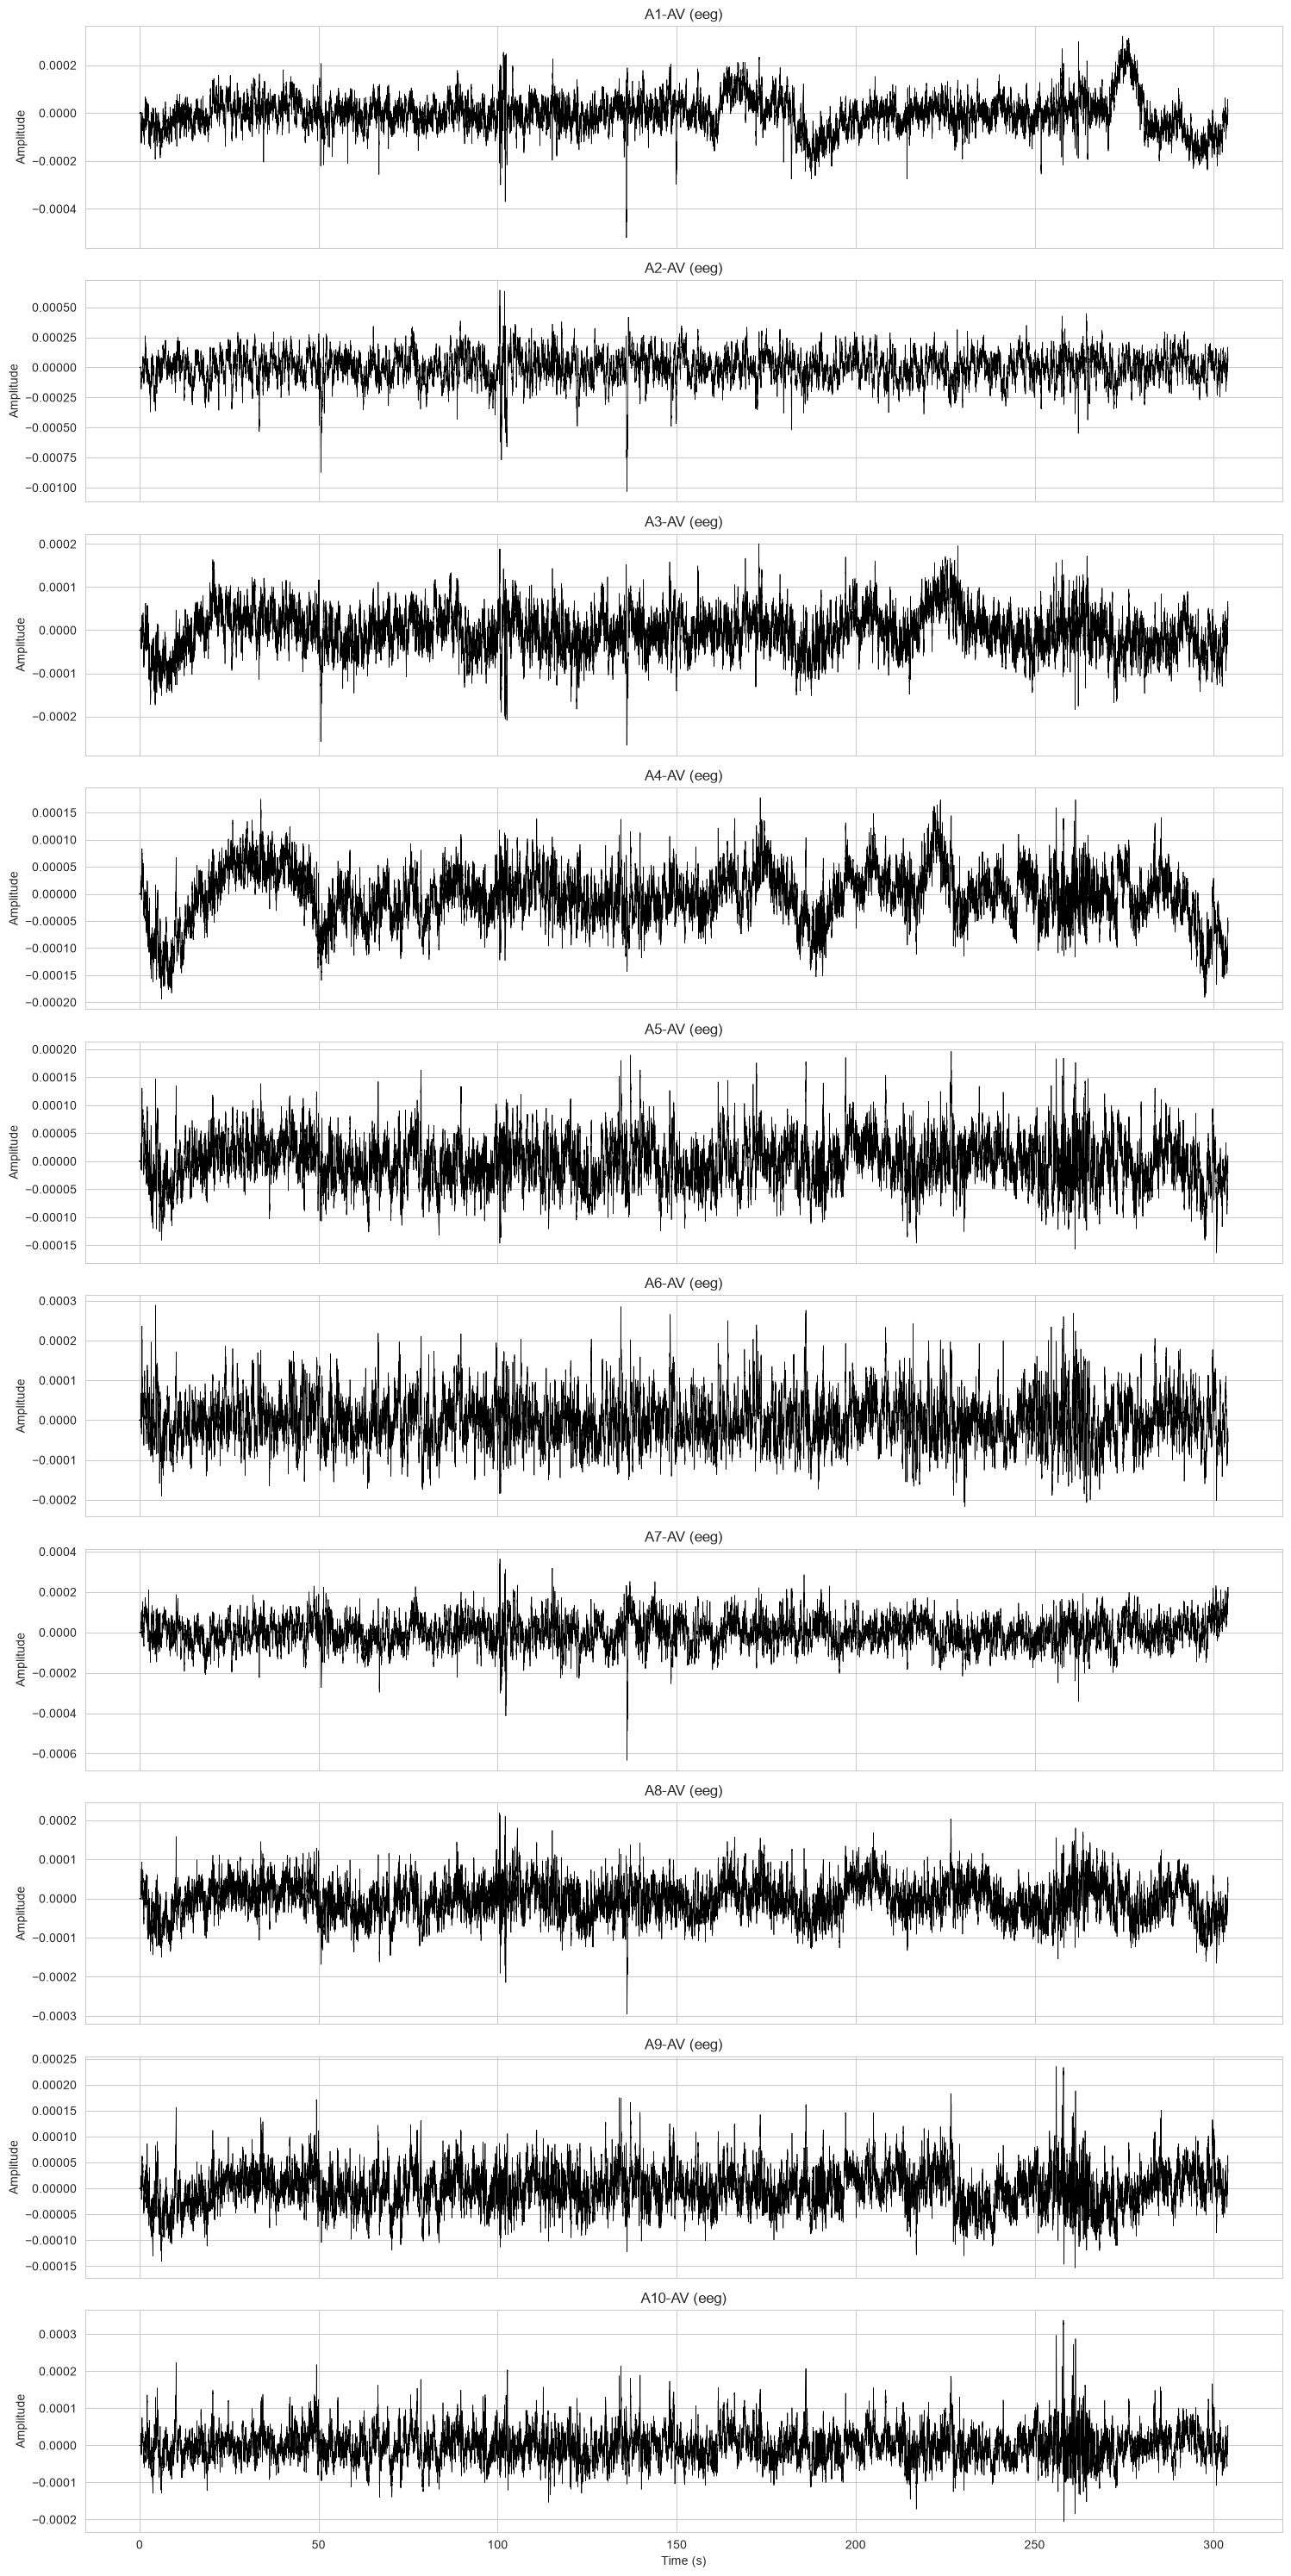

In [9]:
figsize = (15, 3)
channel_indices = np.arange(len(ch_names[0:10]))# [0, 1, 2]
n = len(channel_indices)

end_time = timestamps[-1]
keep = (timestamps >= start_time) & (timestamps <= end_time)

fig, axes = plt.subplots(
    n, 1,
    figsize=(figsize[0], figsize[1] * n),
    sharex=True
)

if n == 1:
    axes = [axes]  # make it iterable when there's only one channel

for ax, ch_idx in zip(axes, channel_indices):
    ax.plot(timestamps[keep], signal[keep, ch_idx], color="black", linewidth=0.5)
    ax.set_title(f"{ch_names[ch_idx]} ({ch_types[ch_idx]})")
    ax.set_ylabel("Amplitude")

axes[-1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

### 3. iEEG data visualization

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_36986/1935738969.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


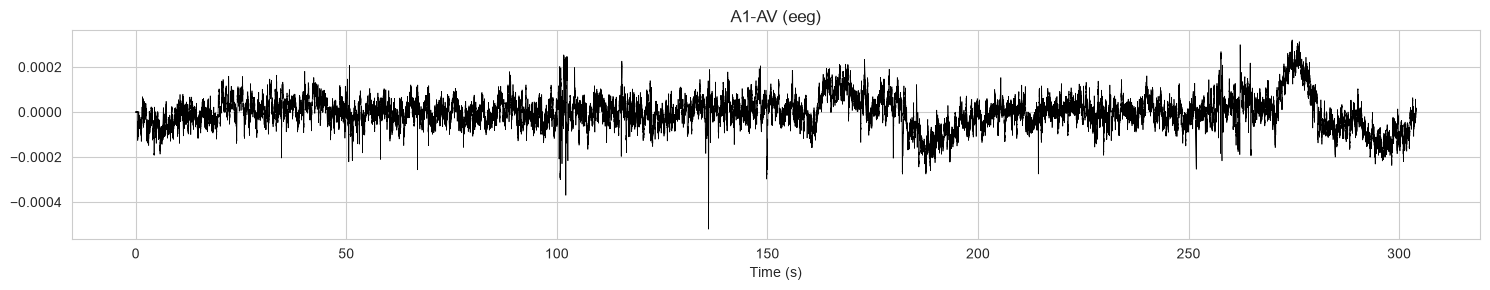

In [10]:
def plot_channel(signal, timestamps, ch_names, ch_types, channel_idx=0, start_time=0, end_time=None, figsize=(15, 3)):
    """Plot one channel's raw signal against time."""
    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(timestamps[keep], signal[keep, channel_idx], color="black", linewidth=0.5)
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{ch_names[channel_idx]} ({ch_types[channel_idx]})")
    fig.tight_layout()
    return fig


fig = plot_channel(signal, timestamps, ch_names, ch_types, channel_idx=0, start_time=start_time)
fig.show()

In [ ]:
def plot_channel_with_hfo_events(
    signal, timestamps, ch_names, ch_types, annotations,
    channel_idx=0, start_time=0, end_time=None, figsize=(15, 3),
):
    """Plot one channel's raw signal with its doctor-annotated HFO events shaded.

    `annotations` is `data.annotations` after merging in HFO events (see
    `foundry.data.pipelines.omni_ieeg._build_annotations`) -- each event has a
    `channel`, `start`/`end` (seconds) and an `artifact` flag (1 = doctor
    marked it as an artifact, not a true HFO).
    """
    fig = plot_channel(signal, timestamps, ch_names, ch_types, channel_idx, start_time, end_time, figsize)
    ax = fig.axes[0]

    ch_name = ch_names[channel_idx]
    on_channel = annotations.channel.astype(str) == ch_name

    legend_handles = {}
    for ev_start, ev_end, artifact in zip(
        annotations.start[on_channel], annotations.end[on_channel], annotations.artifact[on_channel]
    ):
        if ev_start > (end_time if end_time is not None else timestamps[-1]) or ev_end < start_time:
            continue
        label = "HFO (artifact)" if artifact == 1 else "HFO"
        color = "red" if artifact == 1 else "orange"
        ax.axvspan(ev_start, ev_end, color=color, alpha=0.3, lw=0)
        legend_handles[label] = Patch(facecolor=color, alpha=0.3, label=label)

    if legend_handles:
        ax.legend(handles=list(legend_handles.values()), loc="upper right")
    return fig


In [12]:
ch_names

array(['A1-AV', 'A2-AV', 'A3-AV', 'A4-AV', 'A5-AV', 'A6-AV', 'A7-AV',
       'A8-AV', 'A9-AV', 'A10-AV', 'A11-AV', 'A12-AV', 'A13-AV', 'A14-AV',
       'A15-AV', 'A16-AV', 'A17-AV', 'A18-AV', 'A19-AV', 'A20-AV',
       'A21-AV', 'A22-AV', 'A23-AV', 'A24-AV', 'A25-AV', 'A26-AV',
       'A27-AV', 'A28-AV', 'A29-AV', 'A30-AV', 'A31-AV', 'A32-AV',
       'A33-AV', 'A34-AV', 'A35-AV', 'A36-AV', 'A37-AV', 'A38-AV',
       'A39-AV', 'A40-AV', 'A41-AV', 'A42-AV', 'A43-AV', 'A44-AV',
       'A45-AV', 'A46-AV', 'A47-AV', 'A48-AV', 'A49-AV', 'A50-AV',
       'A51-AV', 'A52-AV', 'A53-AV', 'A54-AV', 'A55-AV', 'A56-AV',
       'A57-AV', 'A58-AV', 'A59-AV', 'A60-AV', 'A61-AV', 'A62-AV',
       'A63-AV', 'A64-AV', 'B1-AV', 'B2-AV', 'B3-AV', 'B4-AV', 'B5-AV',
       'B6-AV', 'B7-AV', 'B8-AV', 'B9-AV', 'B10-AV', 'B11-AV', 'B12-AV',
       'B13-AV', 'B14-AV', 'B15-AV', 'B16-AV', 'B17-AV', 'B18-AV',
       'B19-AV', 'B20-AV', 'B21-AV', 'B22-AV', 'B23-AV', 'B24-AV',
       'B25-AV', 'B26-AV', 'B27-AV', 'B2

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_36986/321015820.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_36986/1935738969.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


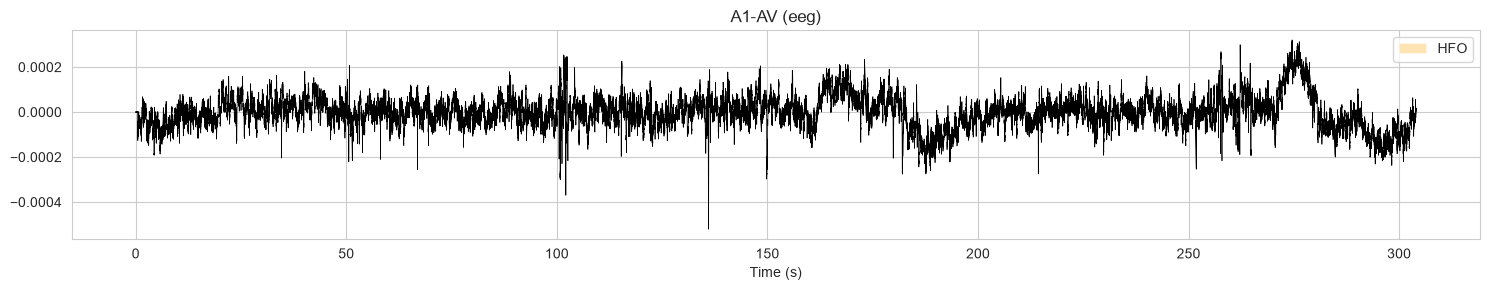

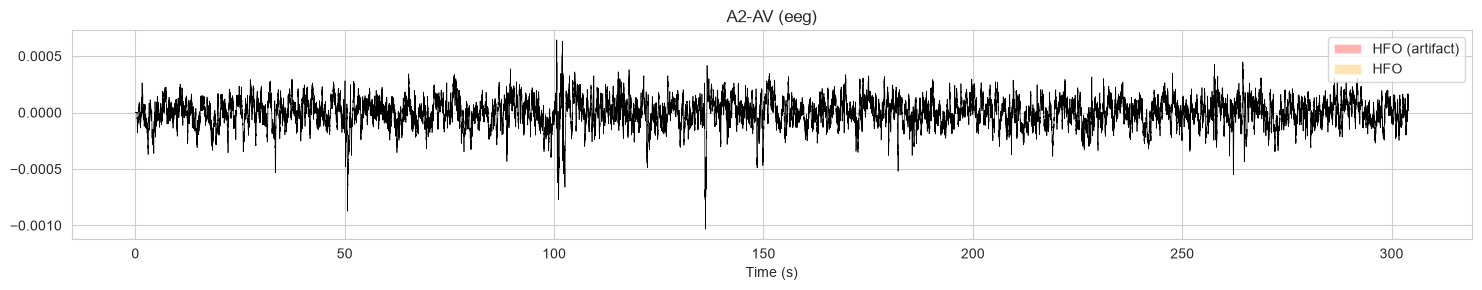

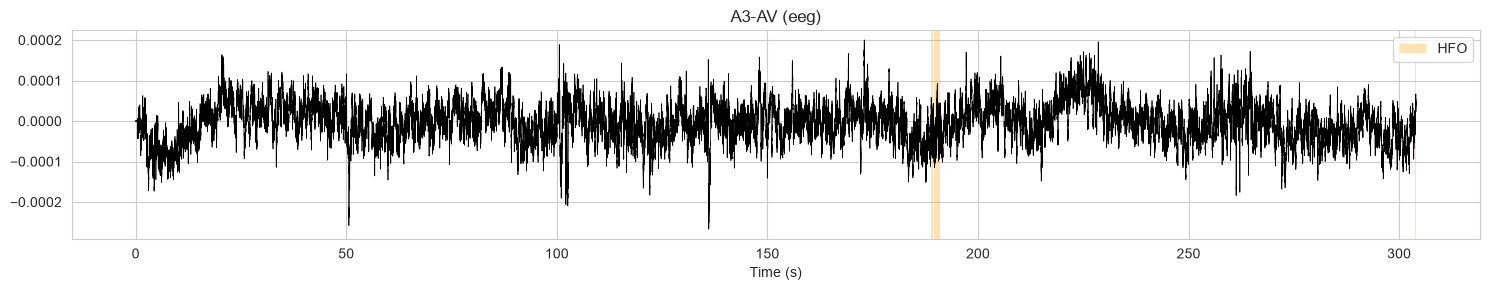

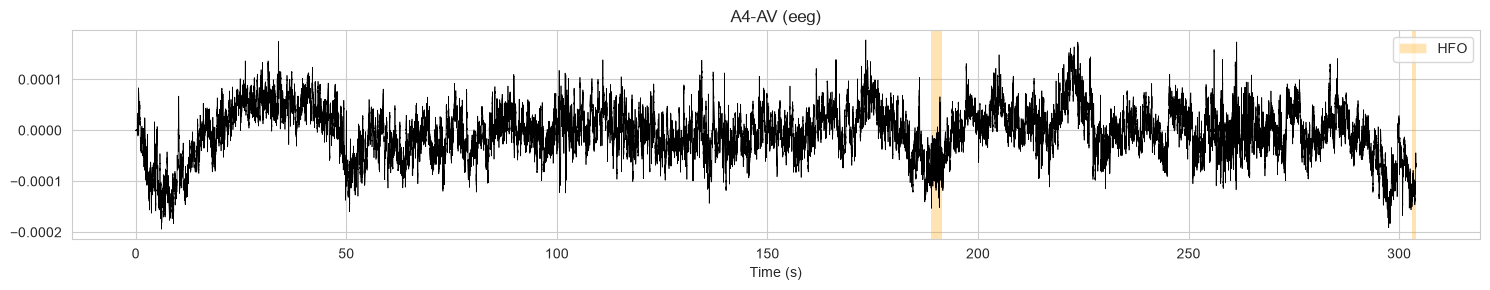

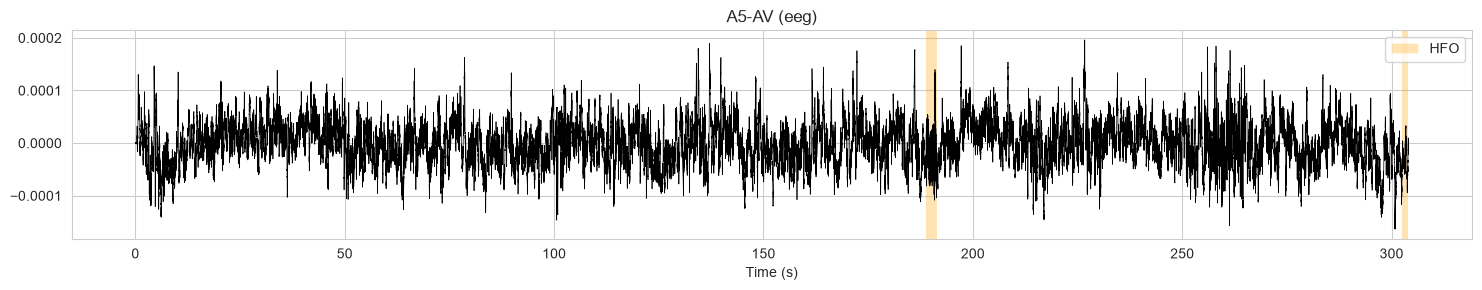

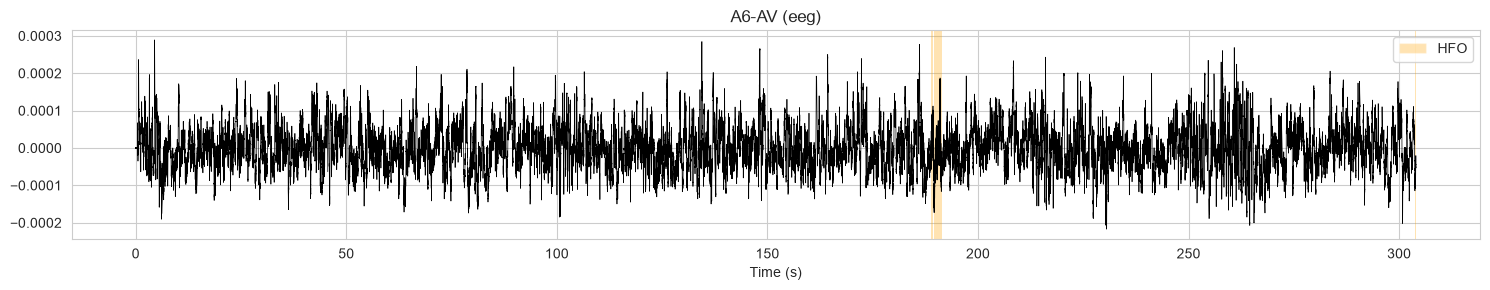

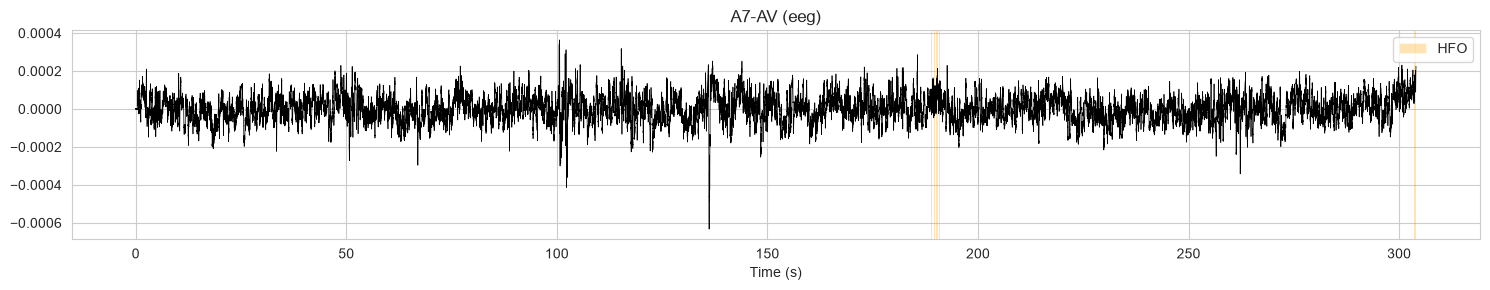

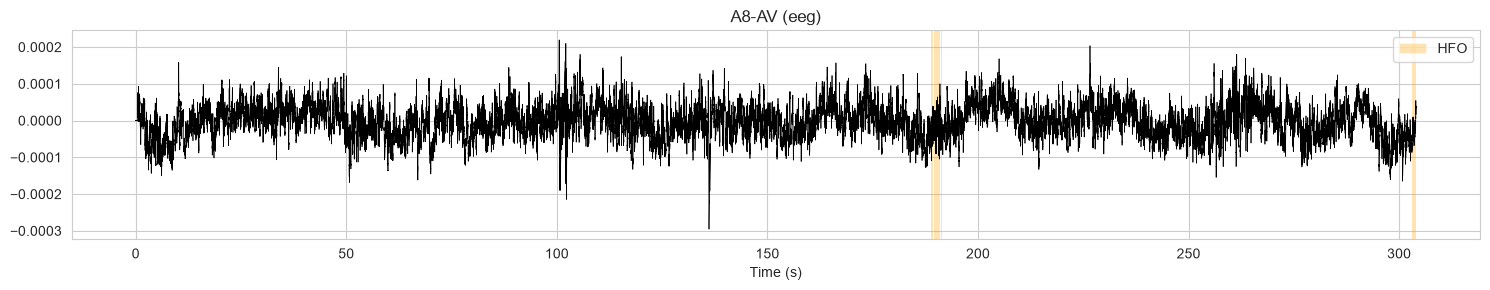

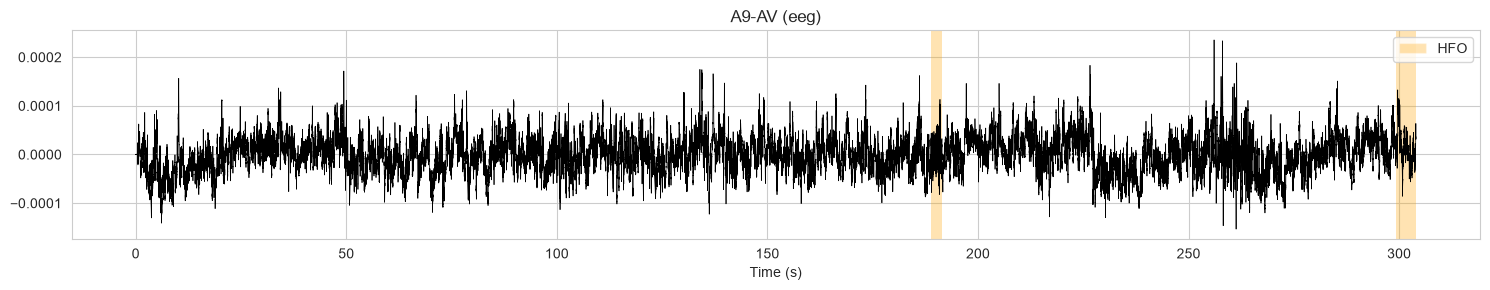

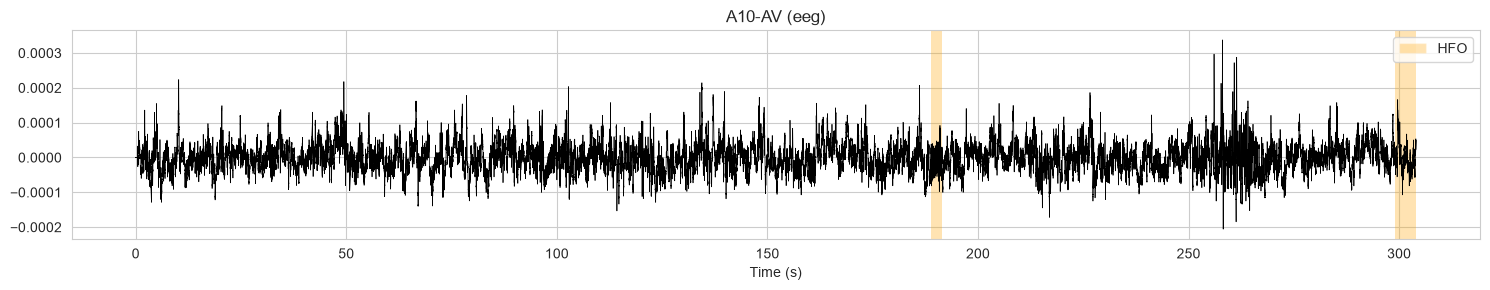

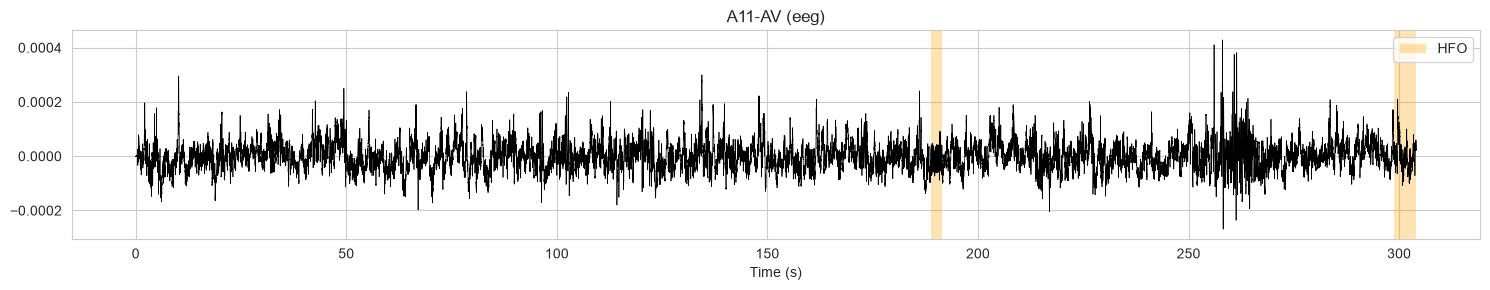

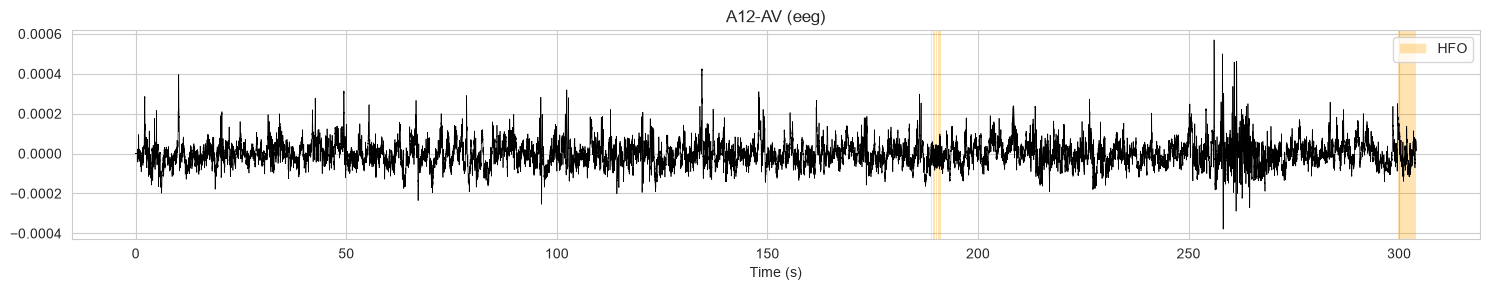

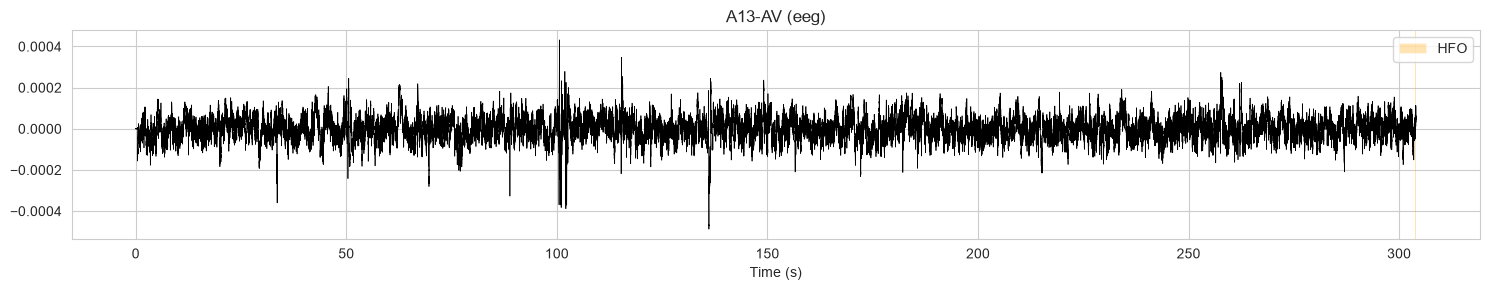

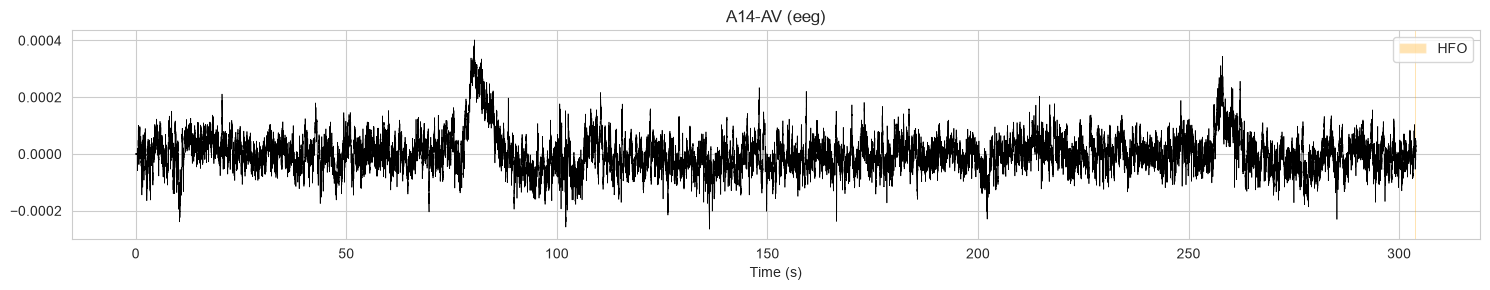

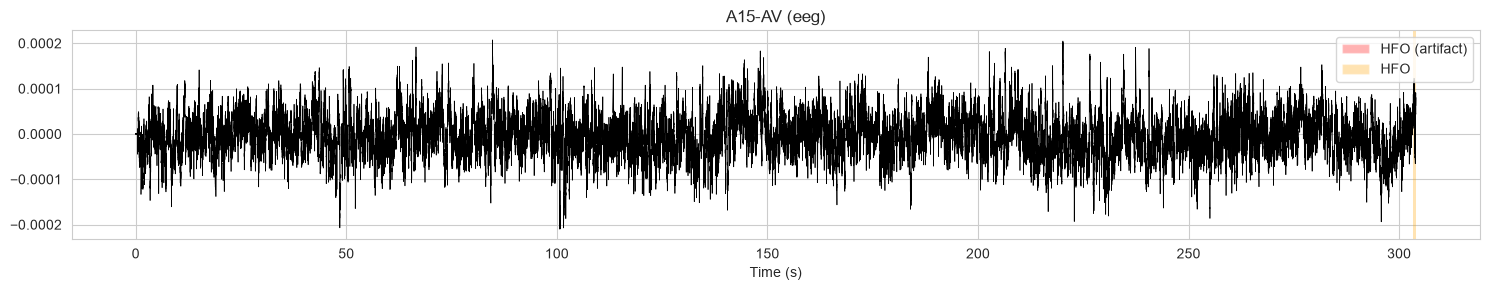

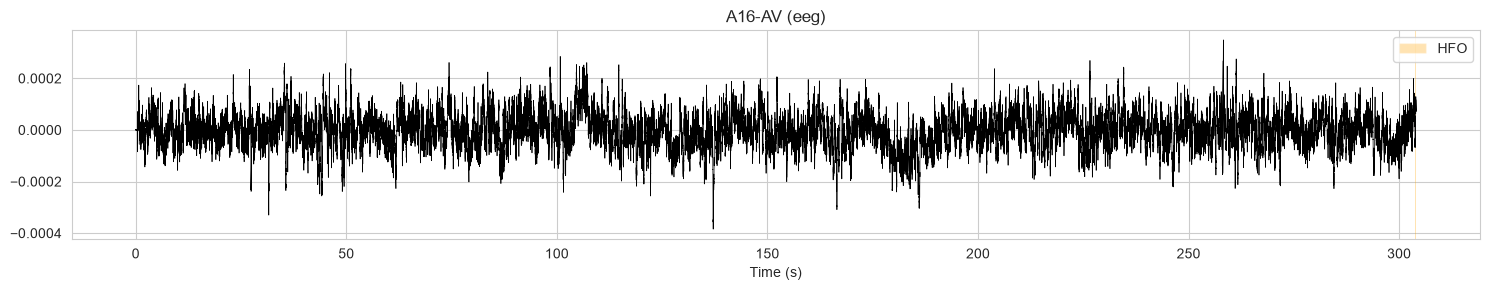

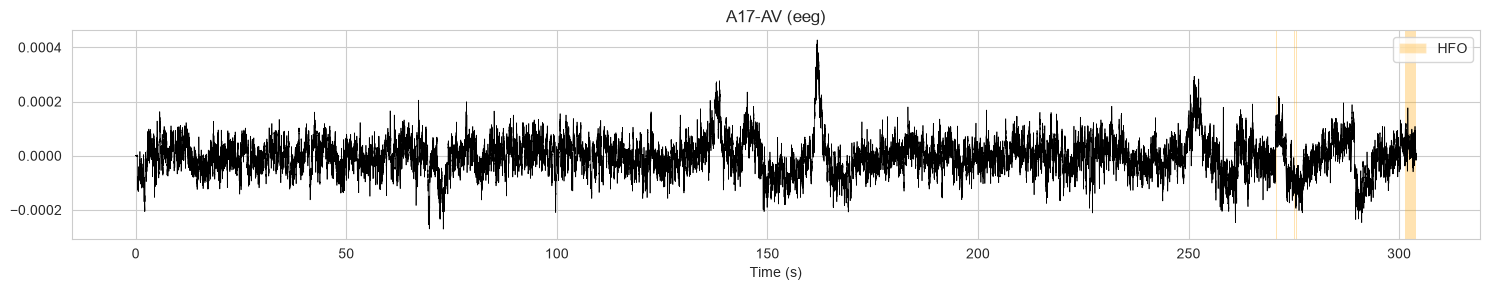

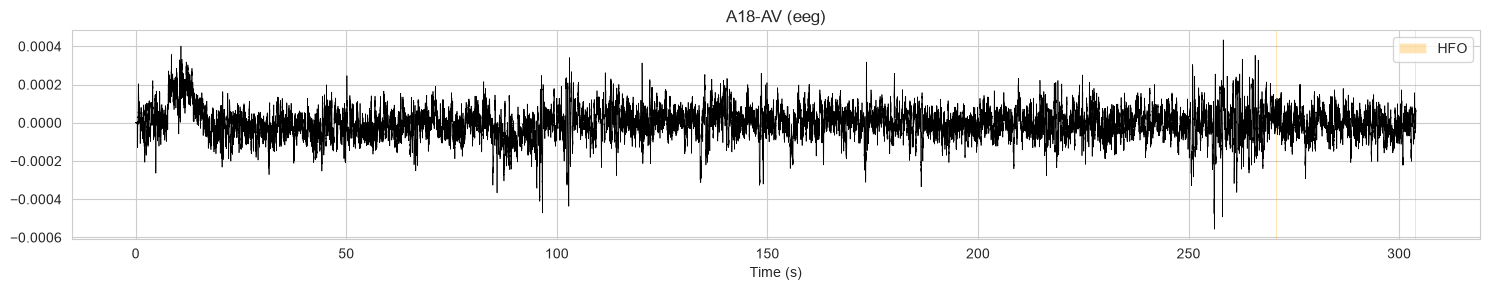

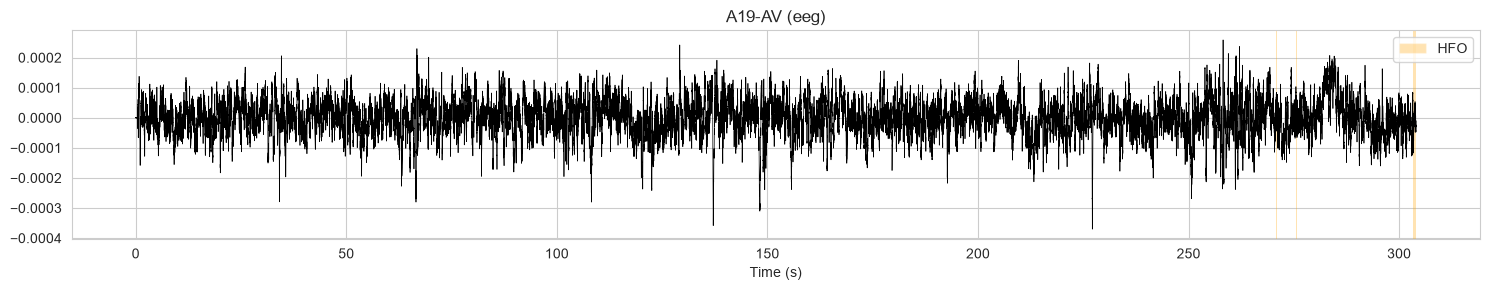

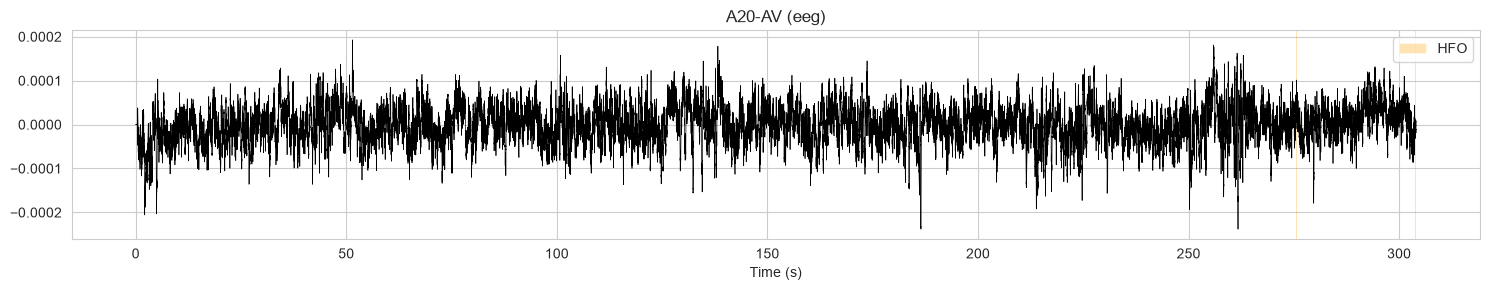

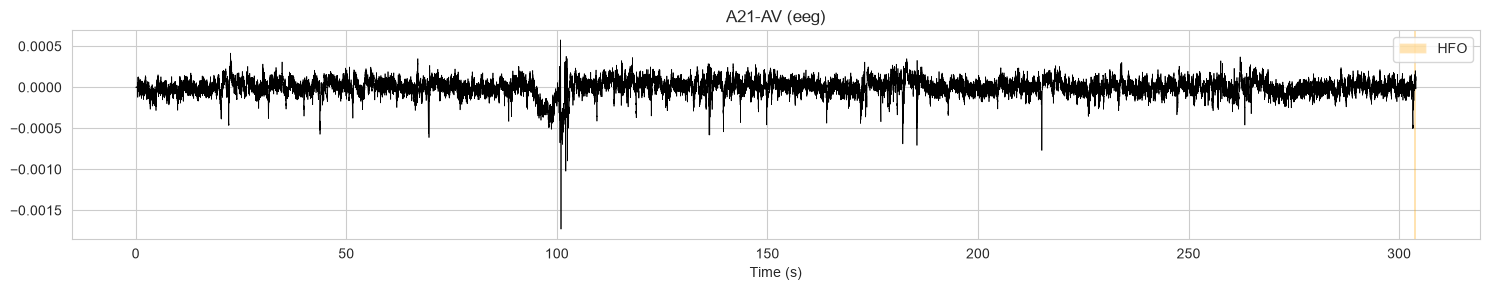

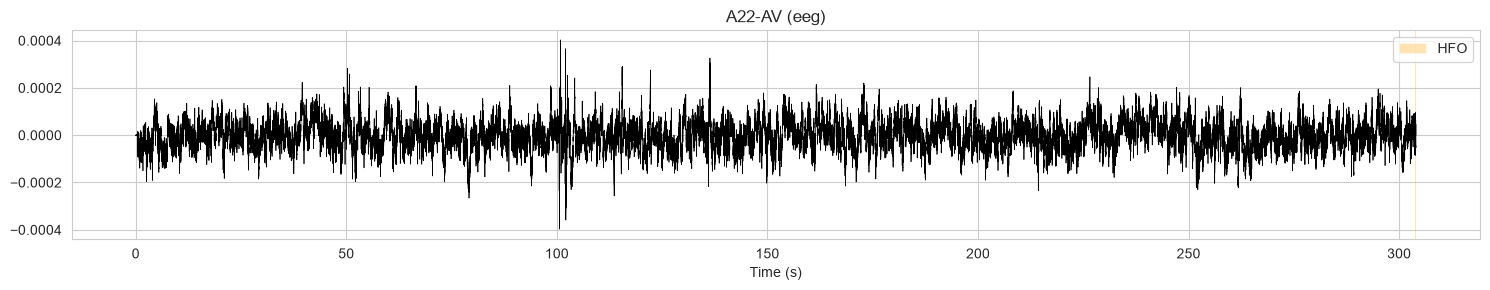

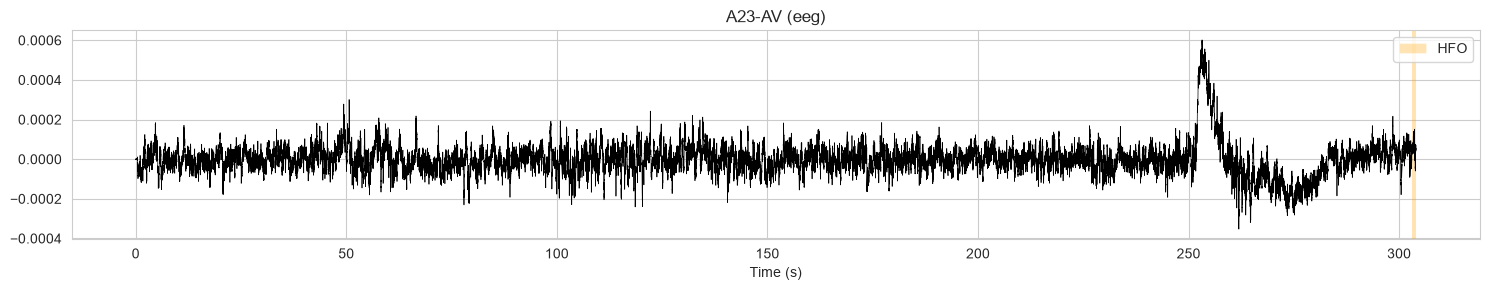

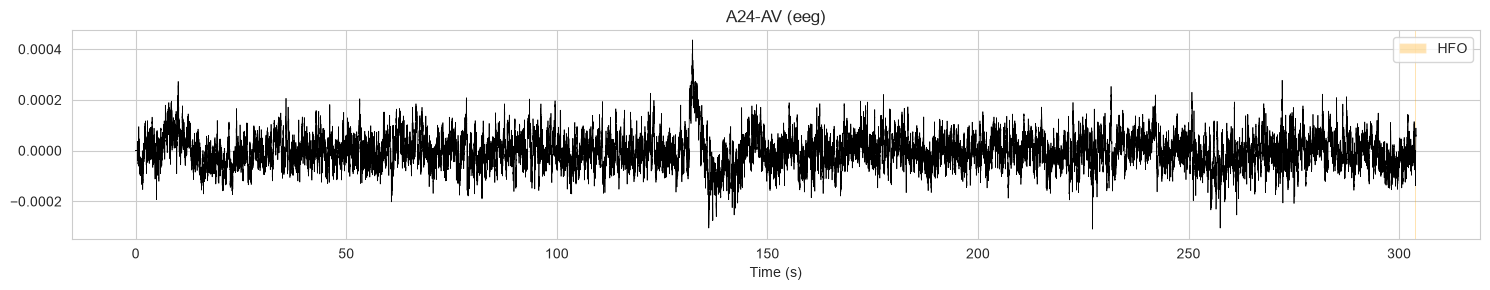

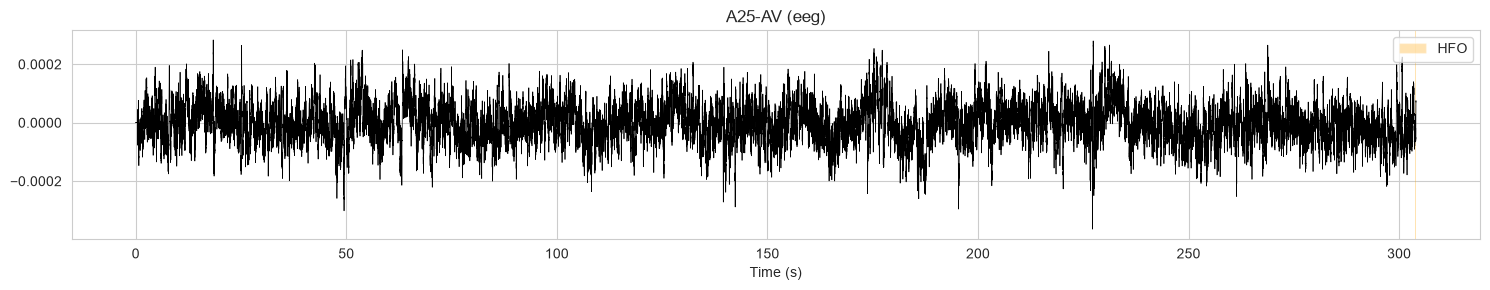

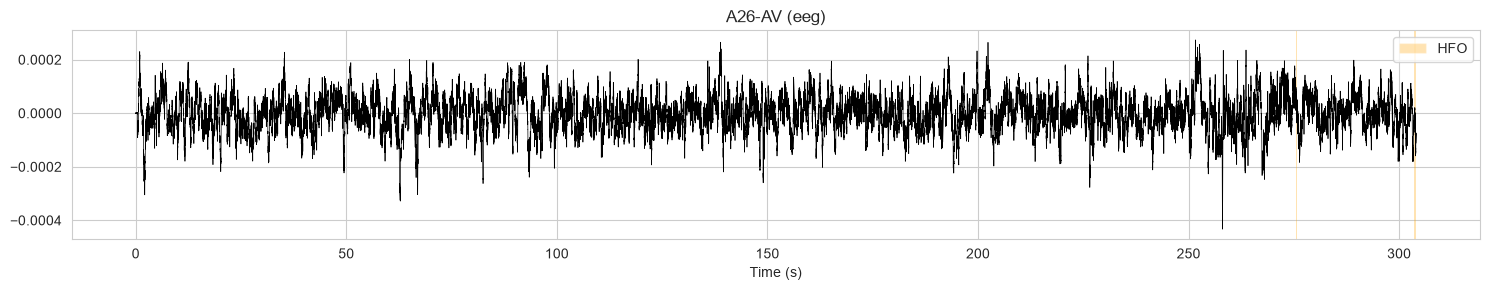

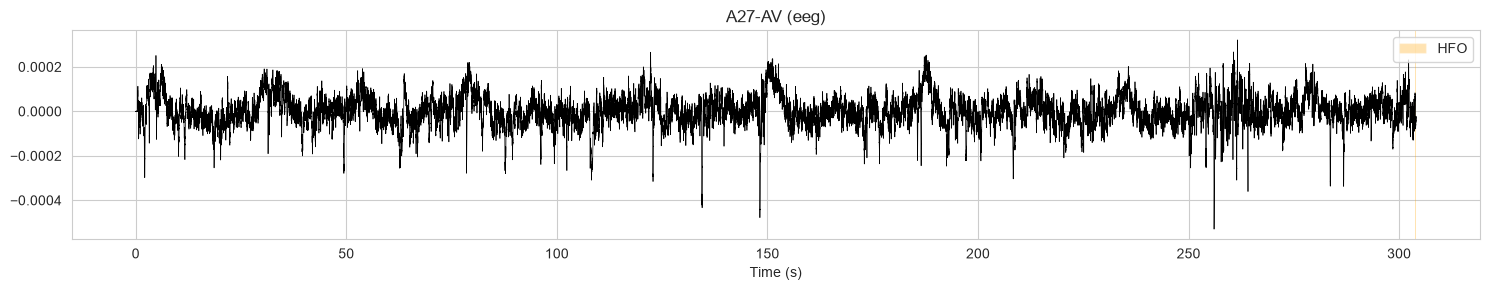

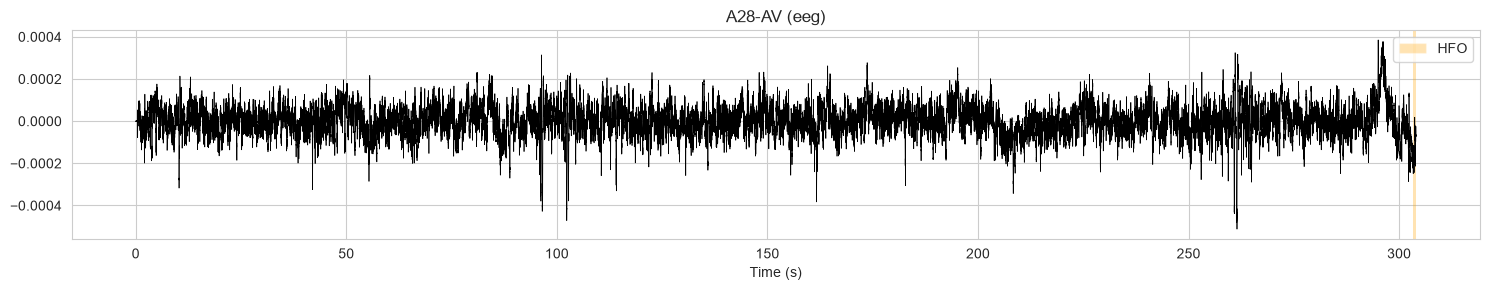

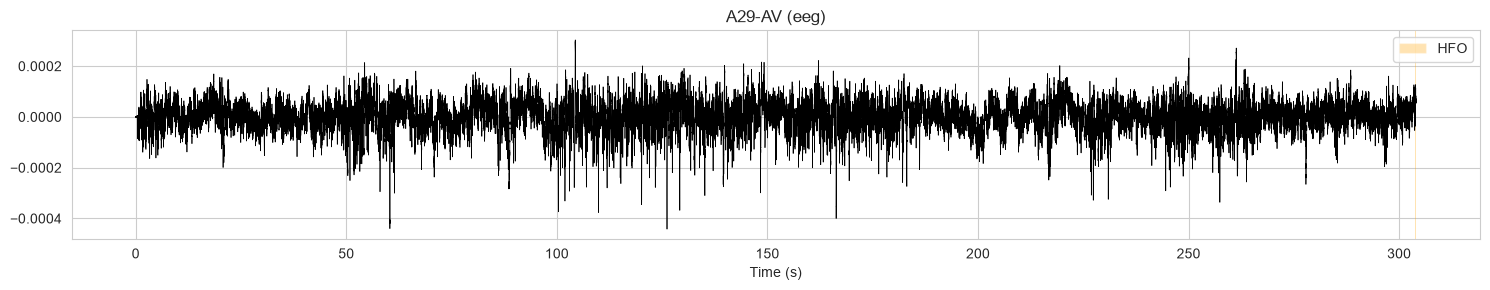

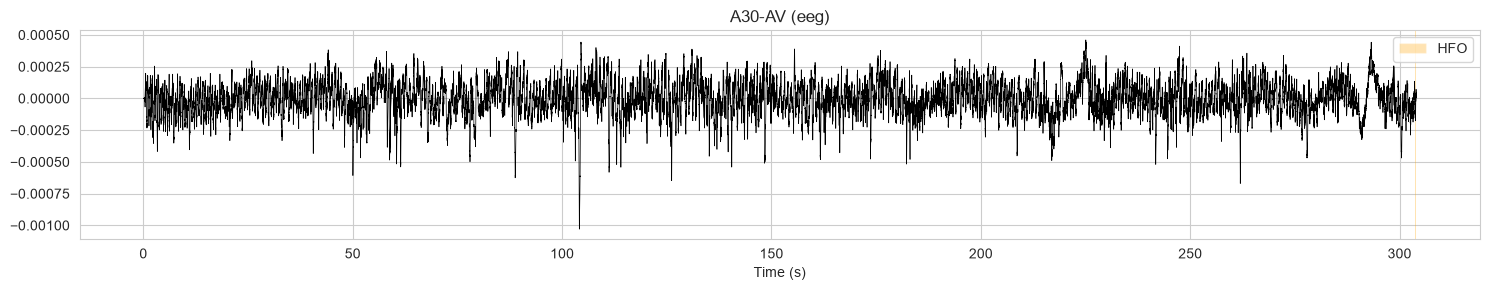

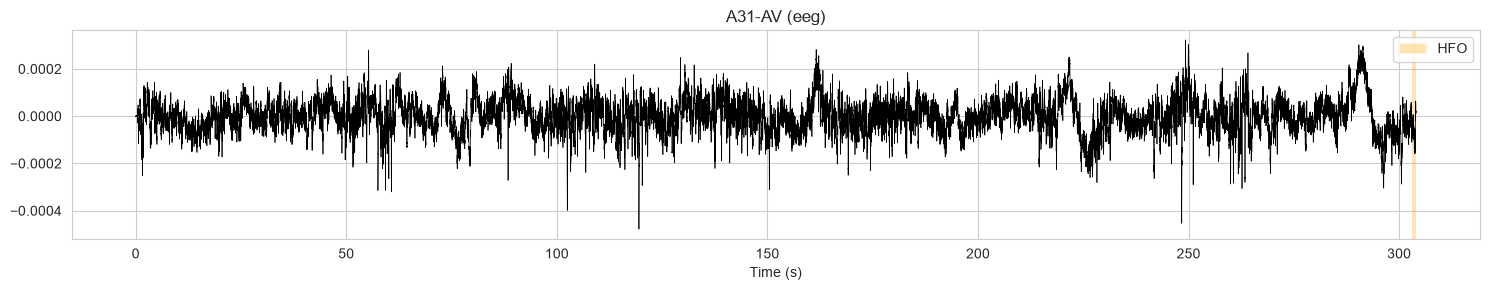

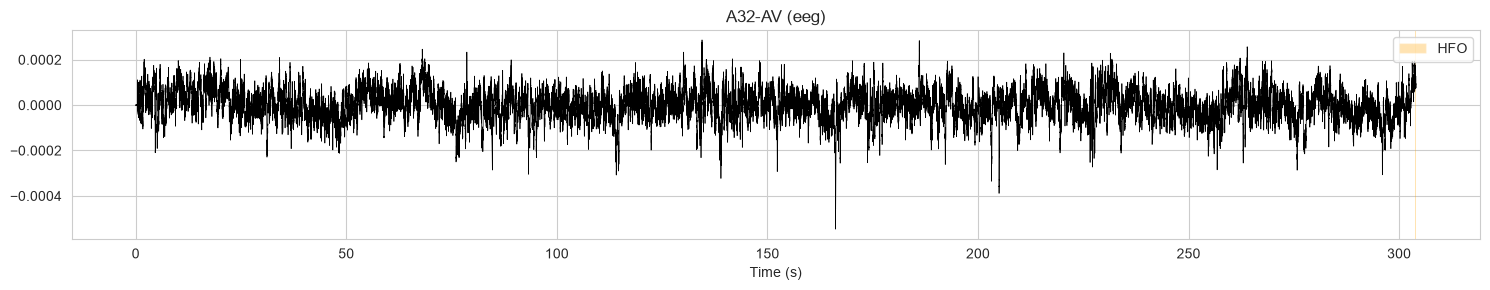

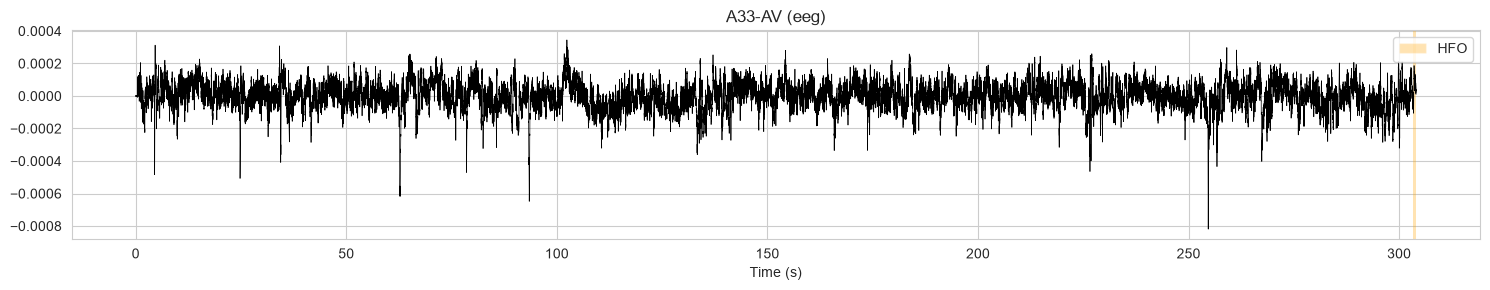

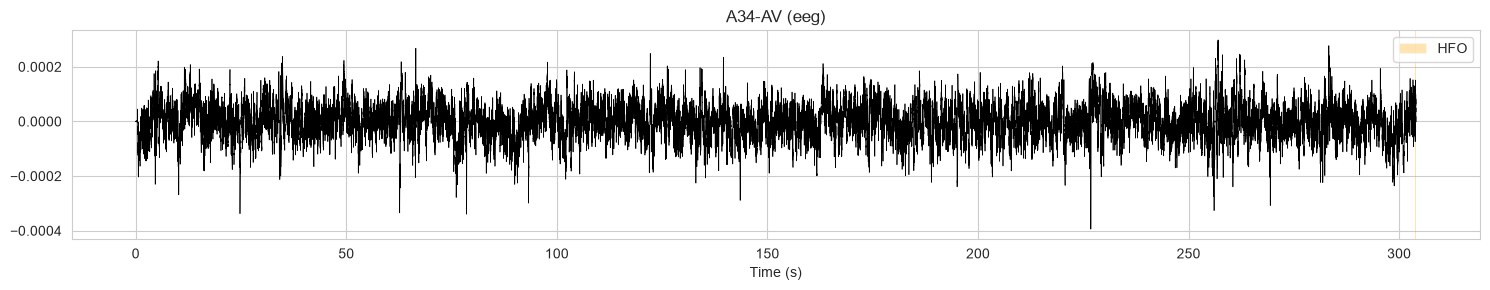

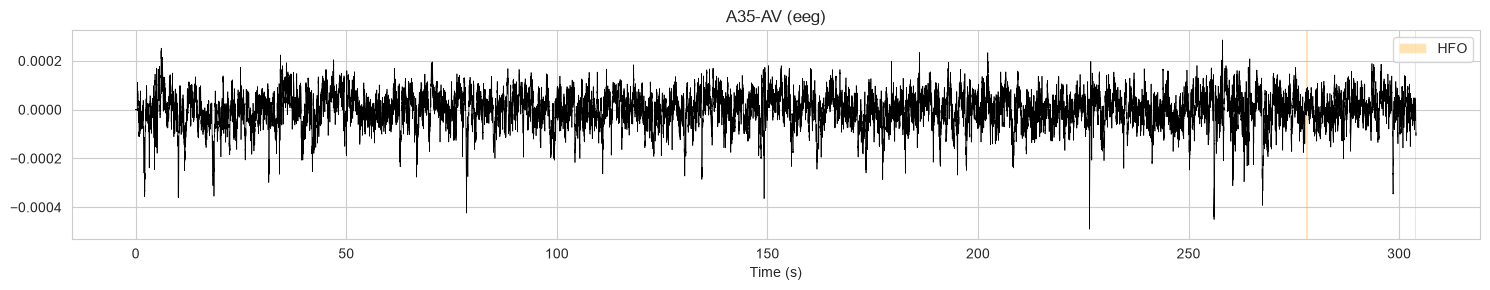

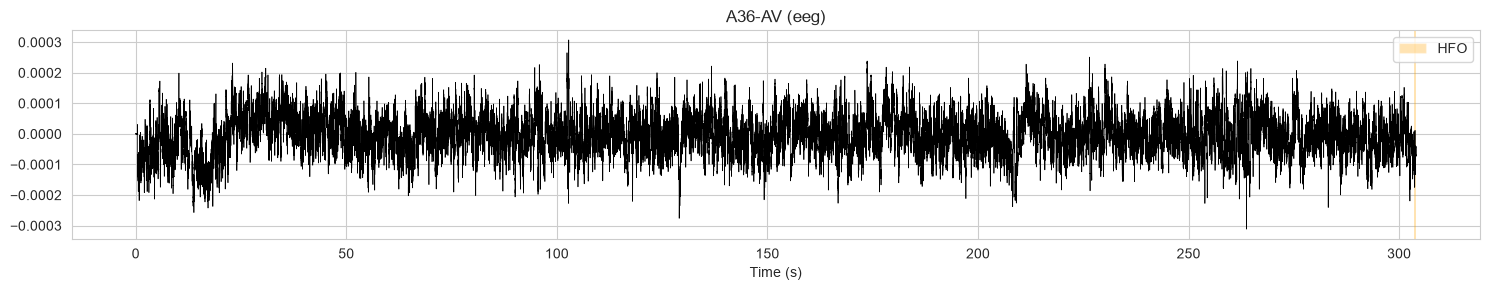

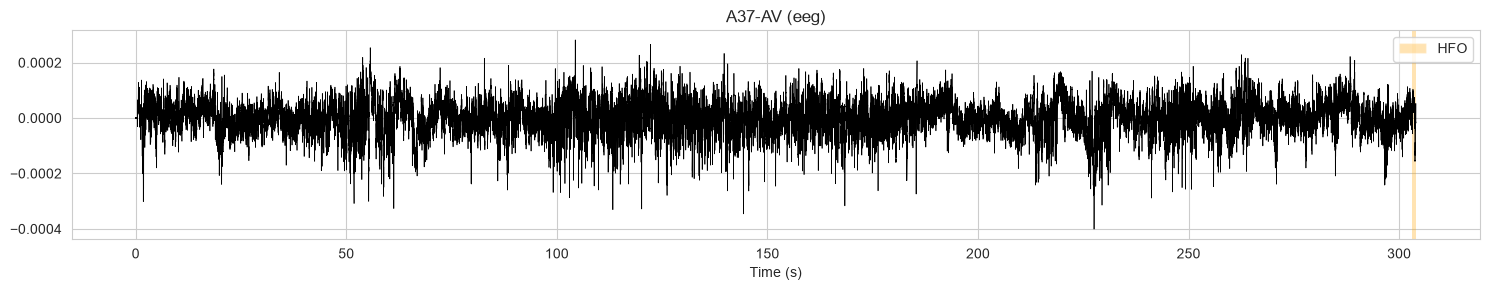

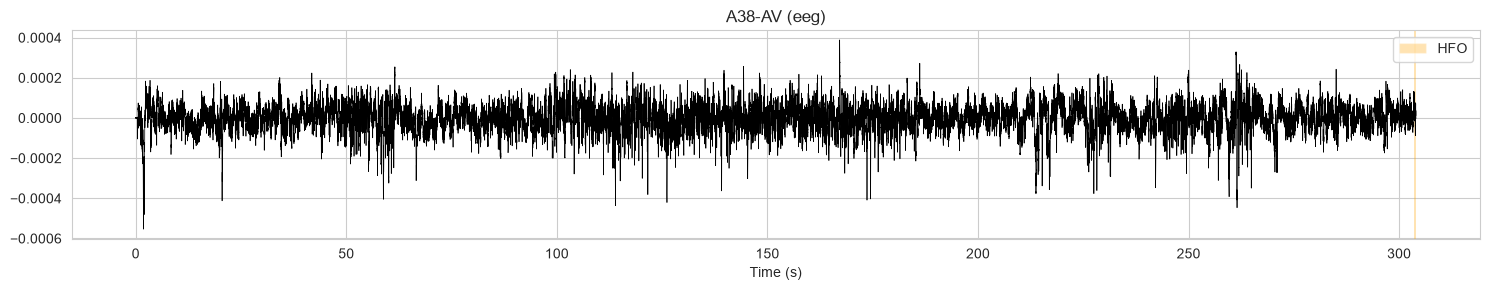

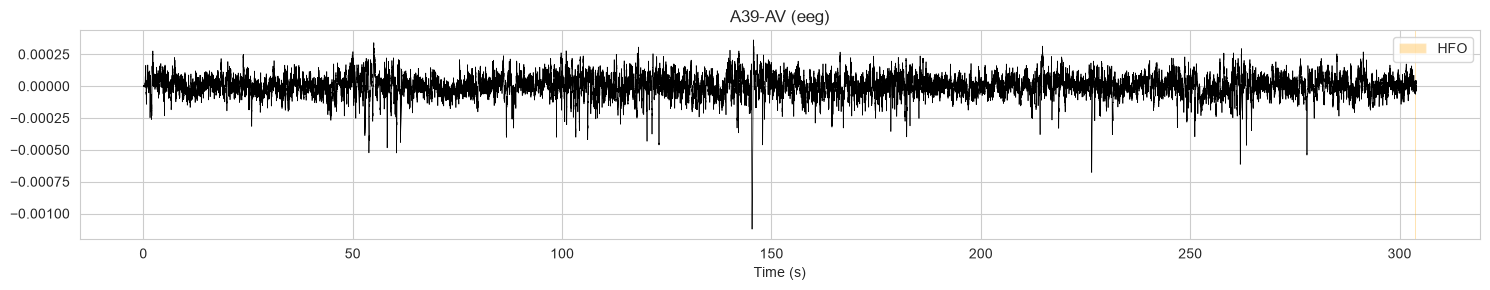

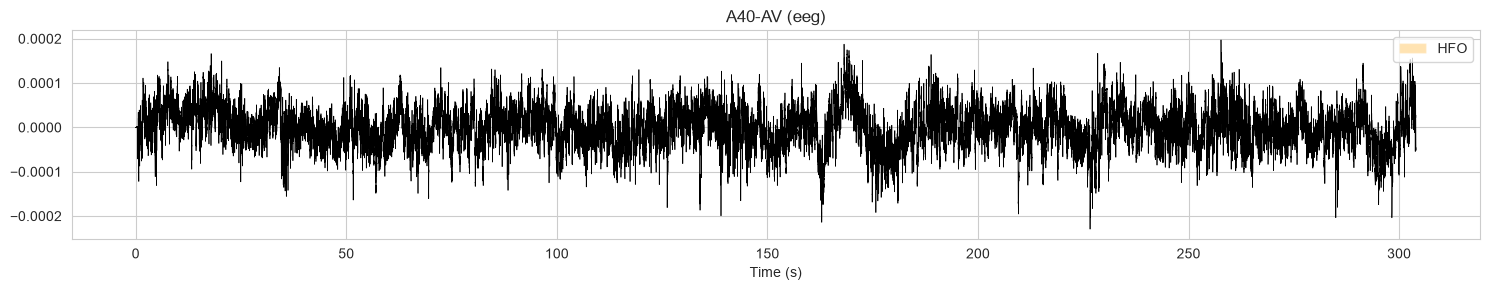

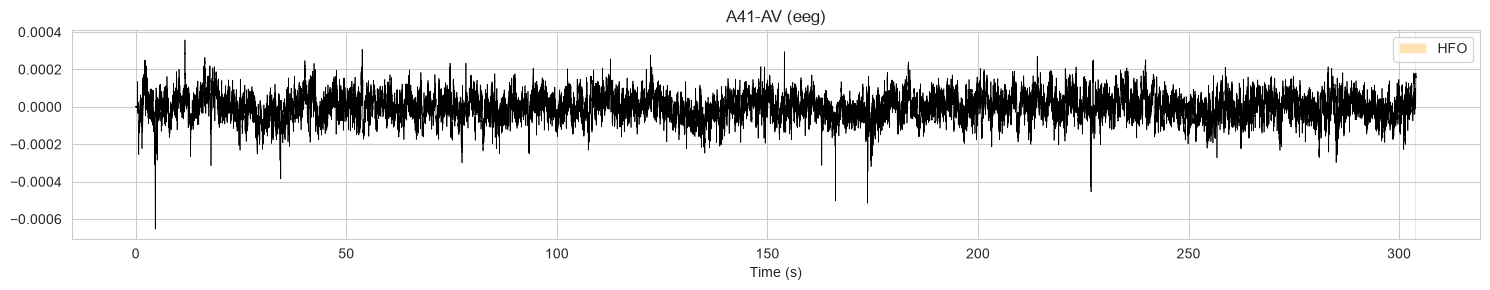

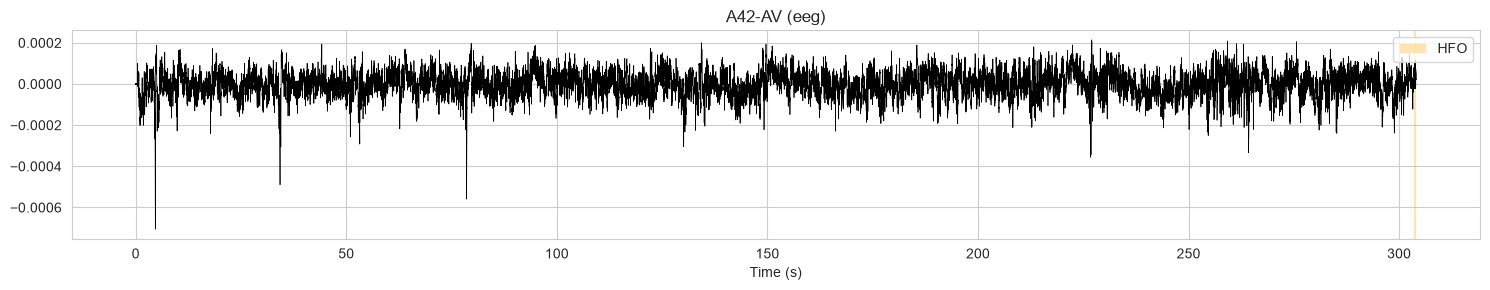

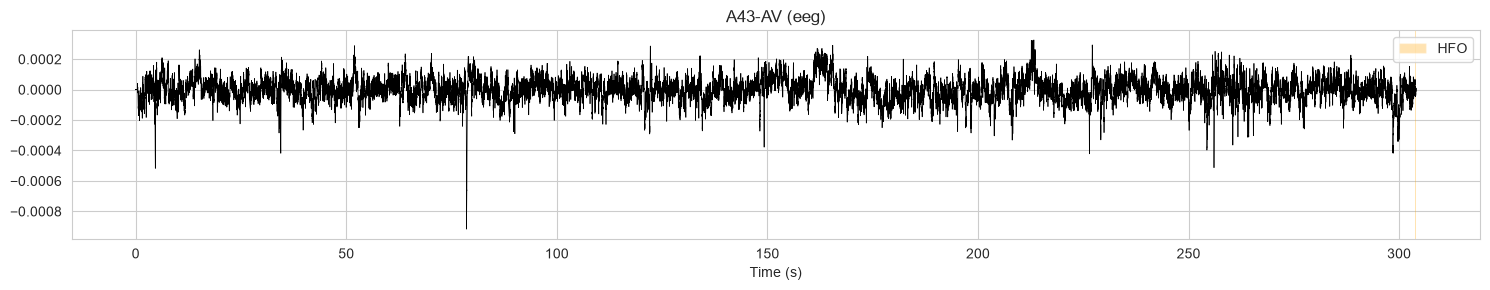

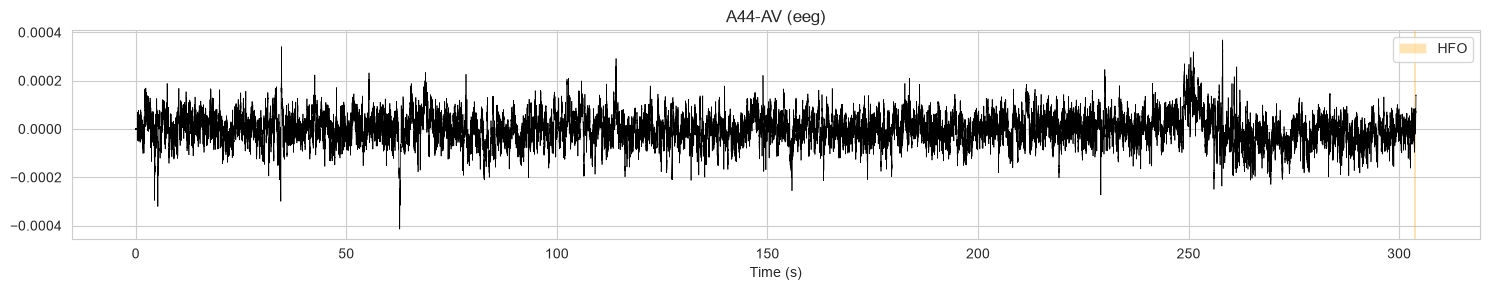

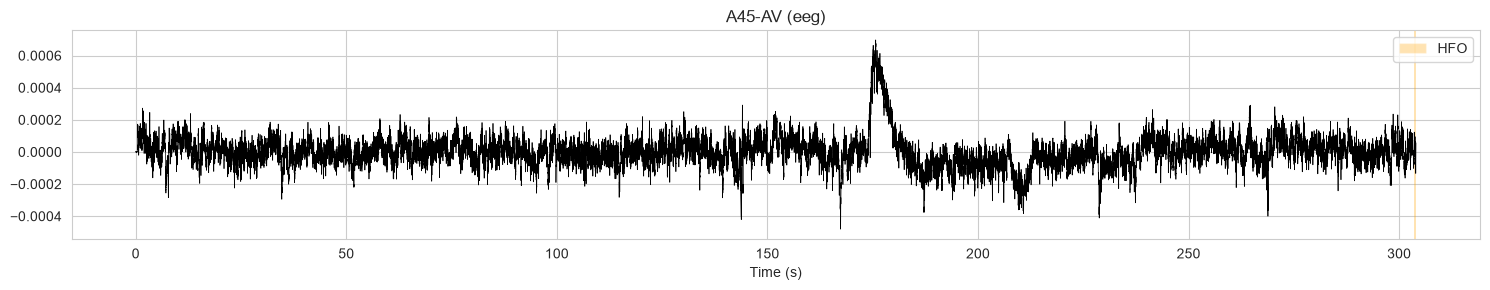

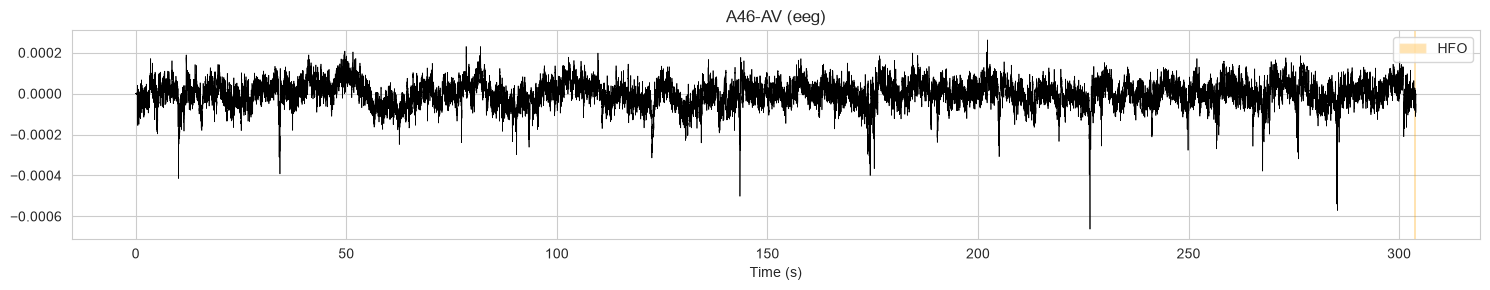

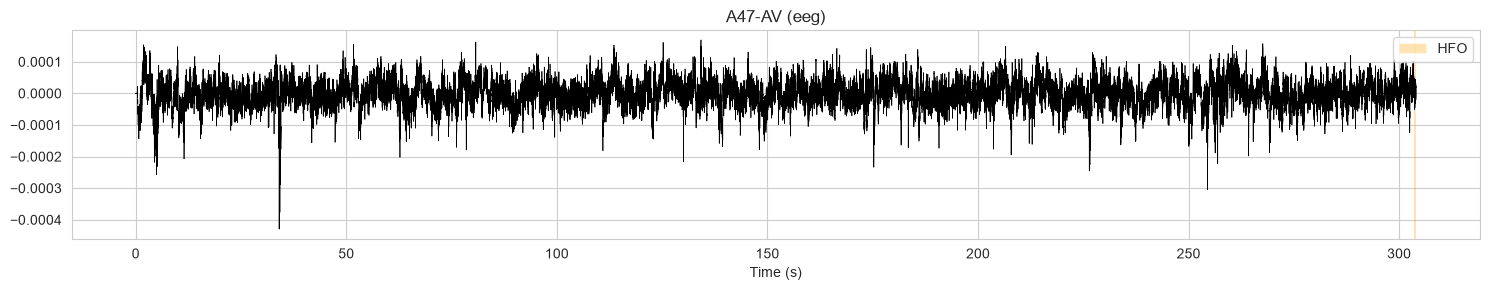

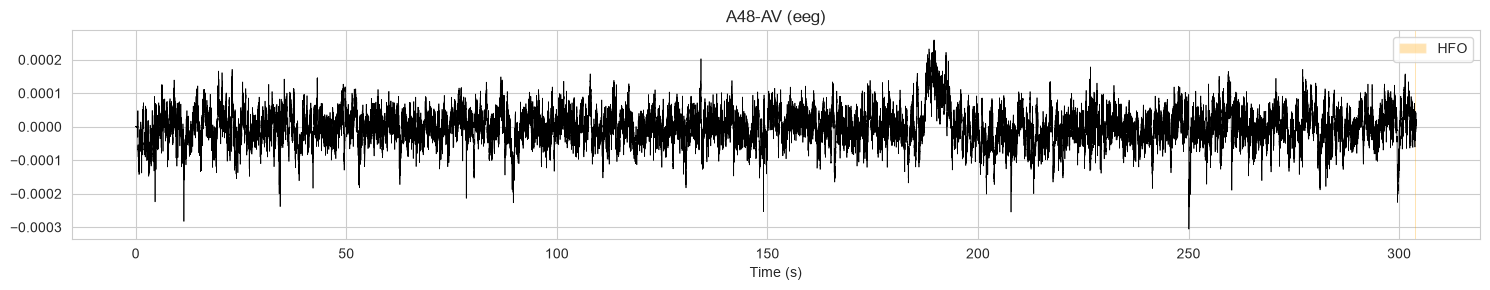

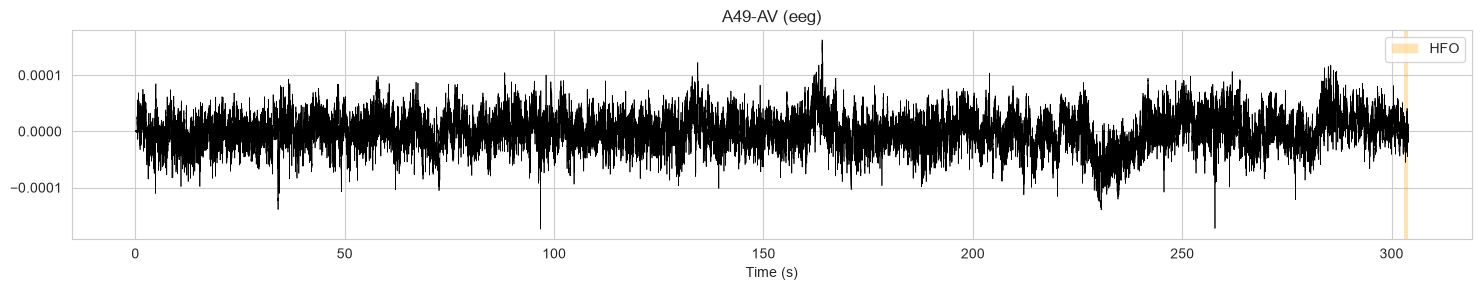

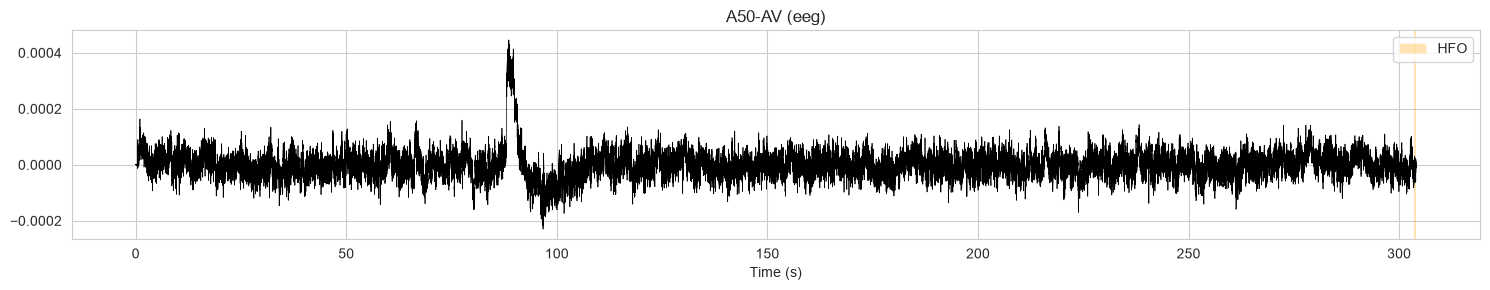

In [14]:
for ch_nbr in np.arange(0,50):
    fig = plot_channel_with_hfo_events(
        signal, timestamps, ch_names, ch_types, data.annotations,
        channel_idx=ch_nbr, start_time=start_time,
    )
    fig.show()

In [15]:
timestamps[-1]

np.float64(303.999)

In [26]:
def _select_ecog_channels(ieeg_signal, ch_names, ch_types):
    """Orient signal as (channels, time) and keep only iEEG/ECoG channels."""
    if ieeg_signal.shape[0] != len(ch_names):
        ieeg_signal = ieeg_signal.T
    is_ecog = np.array([
        typ.lower() in ("ecog", "ieeg", "ecogv", "ecog_hgrid") for typ in ch_types
    ])
    return ieeg_signal[is_ecog, :], np.array(ch_names)[is_ecog]


def _crop_to_window(t, signal, start_time, end_time):
    """Keep only the samples within [start_time, end_time]."""
    if start_time is None:
        start_time = 0
    if end_time is None:
        end_time = t[-1]
    keep = (t >= start_time) & (t <= end_time)
    return t[keep], signal[:, keep]


def _find_gaps(t, gap_threshold):
    """Return the index right before each gap wider than gap_threshold."""
    diffs = np.diff(t)
    if len(diffs) == 0:
        return np.array([], dtype=int)
    if gap_threshold is None:
        gap_threshold = max(2 * np.median(diffs), 1e-6)
    return np.where(diffs > gap_threshold)[0]


def _gap_mask(t, gap_indices):
    """True for samples to keep, False for samples that fall inside a gap."""
    mask = np.ones(len(t), dtype=bool)
    for gap_idx in gap_indices:
        gap_start, gap_end = t[gap_idx], t[gap_idx + 1]
        mask &= ~((t >= gap_start) & (t <= gap_end))
    return mask


def _compress_gaps(t, gap_indices, gap_display_width):
    """Build a display time axis where every gap is squeezed to a fixed width."""
    t_display = np.zeros_like(t)
    t_display[0] = t[0]
    for i in range(1, len(t)):
        step = gap_display_width if (i - 1) in gap_indices else t[i] - t[i - 1]
        t_display[i] = t_display[i - 1] + step
    return t_display


def _draw_gap_spans(ax, t_display, gap_indices, actual_gap_width, gap_display_width):
    """Shade each gap in grey; return a legend handle if any gap was drawn."""
    for gap_idx in gap_indices:
        start, end = t_display[gap_idx], t_display[gap_idx + 1]
        if not actual_gap_width:
            mid = (start + end) / 2
            start, end = mid - gap_display_width / 2, mid + gap_display_width / 2
        ax.axvspan(start, end, color="grey", alpha=0.25, lw=0, zorder=0)

    if len(gap_indices) == 0:
        return None
    return Patch(facecolor="grey", alpha=0.25, label="gap", edgecolor="none")


def _plot_channel_traces(ax, t_display, signal, gap_mask, offset):
    """Plot each channel as a black line, stacked vertically by `offset`."""
    for ch_idx in range(signal.shape[0]):
        trace = signal[ch_idx].astype(float).copy()
        trace[~gap_mask] = np.nan  # break the line across gaps
        ax.plot(t_display, trace + ch_idx * offset, color="black", linewidth=0.5, zorder=1)


def _relabel_compressed_xticks(ax, t_display, t):
    """Map the compressed display-time ticks back to actual recording time."""
    ticks_display = ax.get_xticks()
    ticks_actual = np.interp(ticks_display, t_display, t)
    ax.set_xticklabels([f"{val:.1f}" for val in ticks_actual])


def plot_ieeg_signal(
    ieeg_signal,
    ch_names,
    ch_types,
    start_time=None,
    end_time=None,
    timestamps=None,
    gap_threshold=None,
    actual_gap_width=True,
    gap_display_width=10.0,
    figsize=(15, 8),
):
    """
    Plot iEEG signal as stacked black traces, one per channel.

    Handles irregular timeseries: gaps wider than `gap_threshold` are shown
    as grey shaded regions and the signal is broken (NaN) across them. If
    `actual_gap_width` is False, gaps are squeezed to a fixed width
    (`gap_display_width` seconds) so short segments around a long gap stay
    readable.

    Args:
        ieeg_signal: Signal as (n_channels, n_times) or (n_times, n_channels).
        ch_names (list): Channel names.
        ch_types (list): Channel types (must match ch_names); only iEEG/ECoG
            channels are plotted.
        start_time (float, optional): Start of the plotting window in seconds. Defaults to 0.
        end_time (float, optional): End of the plotting window in seconds. Defaults to the last timestamp.
        timestamps (array): Timestamp (in seconds) of each sample.
        gap_threshold (float, optional): Gap detection threshold in seconds. Defaults to 2x the median inter-sample interval.
        actual_gap_width (bool): Show gaps at their real duration (True) or a fixed width (False). Defaults to True.
        gap_display_width (float): Fixed gap width in seconds, used when `actual_gap_width` is False. Defaults to 10.0.
        figsize (tuple): Figure size.
    """
    signal, ch_names_used = _select_ecog_channels(ieeg_signal, ch_names, ch_types)

    t = np.asarray(timestamps).ravel()
    t, signal = _crop_to_window(t, signal, start_time, end_time)

    gap_indices = _find_gaps(t, gap_threshold)
    gap_mask = _gap_mask(t, gap_indices)
    if not actual_gap_width and len(gap_indices) > 0:
        t_display = _compress_gaps(t, gap_indices, gap_display_width)
    else:
        t_display = t

    fig, ax = plt.subplots(figsize=figsize)
    offset = 5 * np.nanstd(signal)

    gap_legend = _draw_gap_spans(ax, t_display, gap_indices, actual_gap_width, gap_display_width)
    _plot_channel_traces(ax, t_display, signal, gap_mask, offset)

    ax.set_yticks(offset * np.arange(len(ch_names_used)))
    ax.set_yticklabels(ch_names_used)
    ax.set_xlabel("Time (s)")
    ax.set_title("iEEG Signal")
    ax.grid(True, axis="x", linestyle=":")

    if not actual_gap_width:
        _relabel_compressed_xticks(ax, t_display, t)

    if gap_legend is not None:
        ax.legend(handles=[gap_legend], title="Annotations", loc="best", bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

In [51]:
a = signal.T
a.shape

(128, 393000)

#### On (stim) vs Off (no stim) Task

#### Acoustic Stimulation Task 

/Users/avalos/Documents/Programming/neurosoft_epilepsy/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


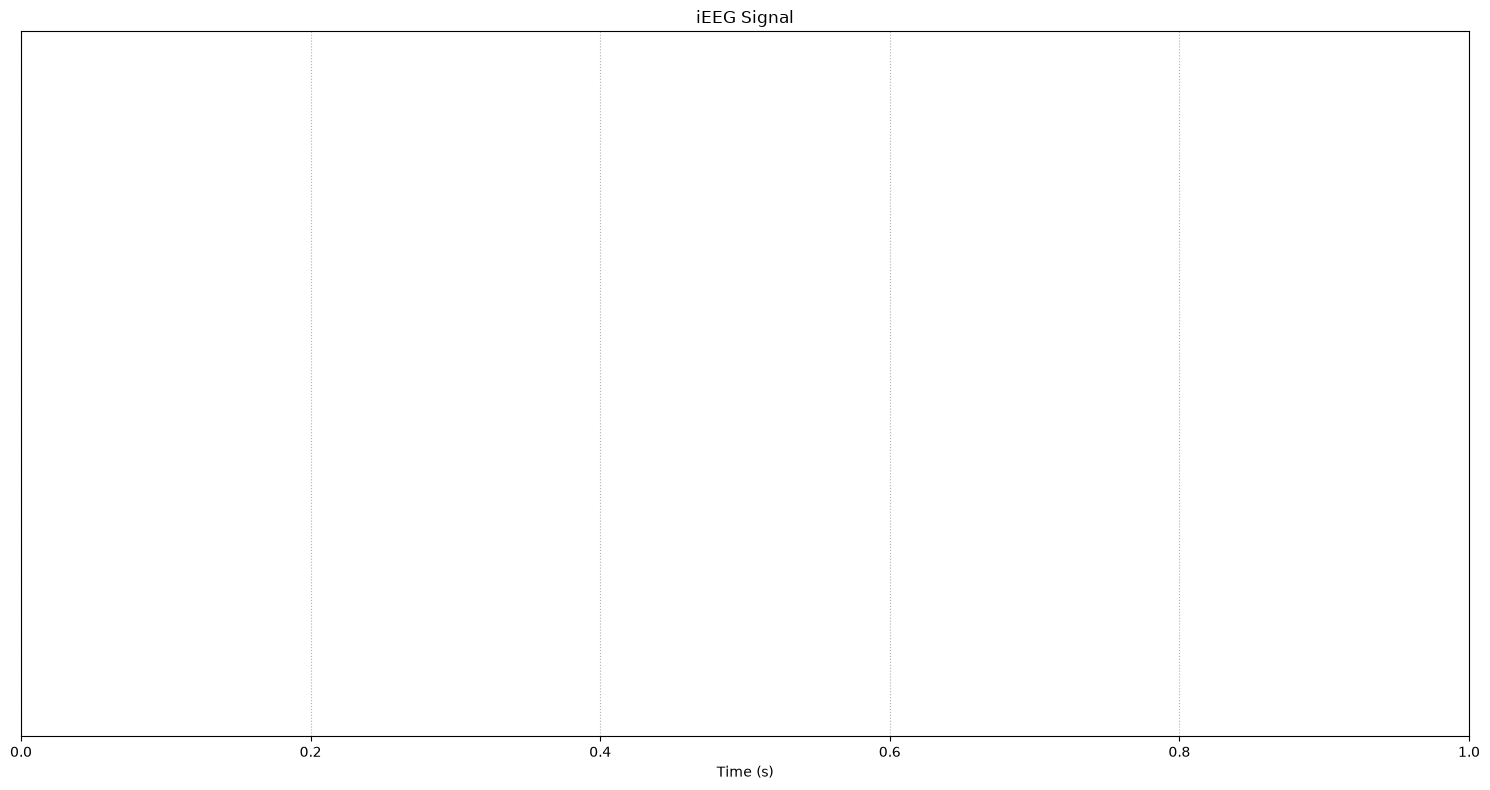

In [74]:
plot_ieeg_signal(
    ieeg_signal=signal.T,
    ch_names=ch_names,
    ch_types=ch_types,
    timestamps=timestamps,
    start_time=start_time,
    end_time=end_time,
    gap_threshold=None,
    actual_gap_width=True,
    gap_display_width=10.0,
    figsize=(15, 8),
)